In [ ]:
# Clean slate — safe to re-run; no-op on cold kernel
get_ipython().run_line_magic('reset','-sf'); import gc, matplotlib.pyplot as plt; plt.close('all'); gc.collect()

# Notebook 11 — Morphing Scores Over Time

> **Supplementary §10**

The morphing shape modes provide a compact coordinate system for describing hawk wing-tail shape. This notebook examines how the morphing mode scores vary over the course of a flight, revealing the temporal dynamics of shape change.

We consolidate results from four perspectives:
1. **All modes at a glance** — the full 9-mode score trajectories for control and obstacle flights
2. **Flight distance** — how morphing patterns differ across 5 m, 7 m, 9 m, and 12 m flights
3. **Obstacle flights** — how the presence of an obstacle alters morphing trajectories, per hawk
4. **Individual variation** — per-hawk morphing patterns under different conditions

Scores are binned by horizontal distance to the landing perch and plotted as mean ± 1 standard deviation.

## Contents
1. [Setup and data loading](#setup)
2. [All morphing modes at a glance](#all-modes)
3. [Effect of flight distance](#flight-distance)
4. [Obstacle versus control flights](#obstacle)
5. [Individual variation and context effects](#individual)
    - [Per-hawk scores — control flights](#per-hawk-control)
    - [Effect of added weight](#weight)
    - [Naive vs experienced hawks](#naive-experienced)
6. [Summary](#summary)

In [2]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df,
)
from kinematic_morphospace.plotting import (
    plot_score, plot_score_multi_PCs, plot_score_multi_distance,
    plot_score_multi_bird,
    plot_score_obstacle_control, plot_score_weight_control,
    plot_score_naive_control,
    save_figure,
)

# ── Configuration ──
CONFIG = {
    "bin_size": 0.2,       # horizontal-distance bin width (m)
    "fig_dir": "../../figures/supplementary",
}

## Load Data and Run PCA

We load the rotation-corrected unilateral marker data and rerun PCA (trained on non-obstacle flights, projected onto all data). The scores are then combined with flight metadata and binned by horizontal distance.

In [3]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=CONFIG["bin_size"])

# ── Data summary ──
print(f"Total frames:  {scores.shape[0]:,}")
print(f"Modes:         {scores.shape[1]}")
print(f"Scores df:     {scores_df.shape}")
print()
n_obs   = filter_by(unilateral_frame_info_df, obstacle=0).sum()
n_obst  = filter_by(unilateral_frame_info_df, obstacle=1).sum()
n_naive = filter_by(unilateral_frame_info_df, naive=1).sum()
n_exp   = filter_by(unilateral_frame_info_df, naive=0).sum()
print(f"Non-obstacle:  {n_obs:,}")
print(f"Obstacle:      {n_obst:,}")
print(f"Experienced:   {n_exp:,}")
print(f"Naive:         {n_naive:,}")

  Sign conventions applied: PC07 negated (positive = m-folded)
Total frames:  289,528
Modes:         12
Scores df:     (289528, 27)

Non-obstacle:  252,630
Obstacle:      36,898
Experienced:   95,498
Naive:         194,030


## All Morphing Modes at a Glance

> **§10.1**

**Note on mode ordering:** For clarity, "collective pitching" (PC08) has been repositioned in these plots; the scores are therefore not strictly ordered by variance explained.

The 3×3 grids below show binned score trajectories for all 9 morphing modes during 9 m flights (experienced hawks, 2020). Comparing the control and obstacle panels side by side reveals which modes are perturbed by the obstacle manoeuvre and which remain largely unchanged.

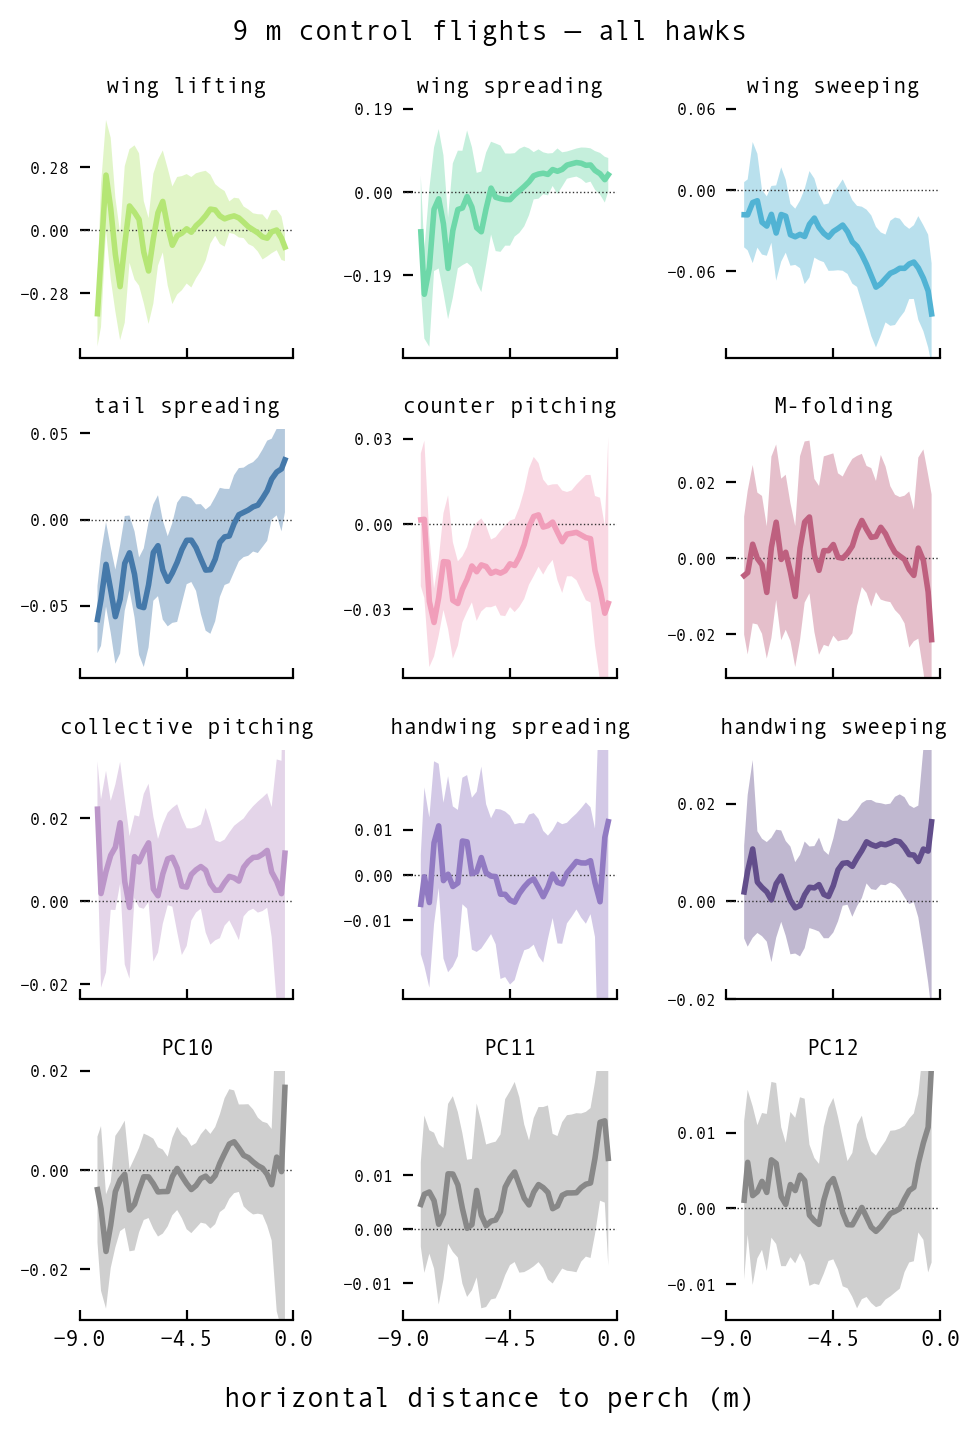

In [4]:
plt.close("all")
fig = plot_score_multi_PCs(scores_df, perchDist=9, obstacle=0, year=2020)
plt.suptitle("9 m control flights — all hawks", fontsize=10, y=1.02)
plt.show()

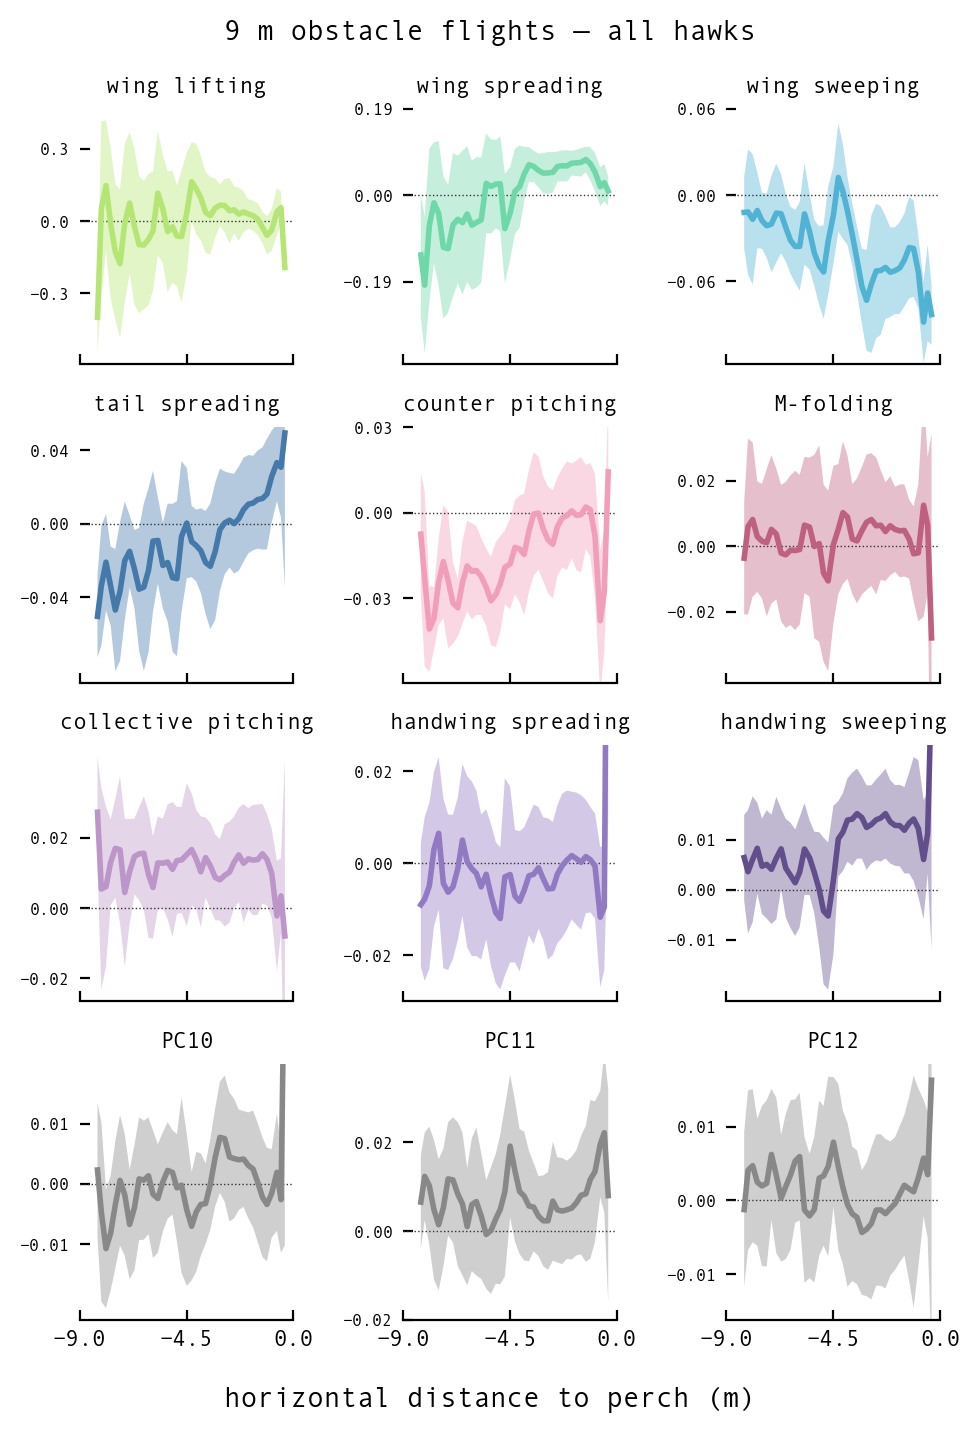

In [5]:
plt.close("all")
fig = plot_score_multi_PCs(scores_df, perchDist=9, obstacle=1, year=2020)
plt.suptitle("9 m obstacle flights — all hawks", fontsize=10, y=1.02)
plt.show()

Compared to the control flights, the obstacle flights show several distinctive features around the obstacle at the midpoint (~4–5 m from the perch):

- **Wing sweep (Mode 3) and hand-wing sweep (Mode 9):** Both show increased activity around the obstacle. Wing sweep dips then rises sharply (Δ ≈ +0.025 at 4 m from the perch), while hand-wing sweep is elevated through the manoeuvre region — consistent with the hawks adjusting both proximal and distal wing sweep to bank around the obstacle.
- **Counter-pitching (Mode 5):** More negative throughout the obstacle region (Δ ≈ −0.01), indicating the tail is lowered while the wings pitch in the opposite direction. This is consistent with tail banking for yaw control during the turn.
- **Collective pitching (Mode 8):** Shows a brief perturbation around the obstacle — a dip followed by a recovery — suggesting transient whole-wing pitch adjustments during the manoeuvre.

The dominant modes (1–2) are less systematically affected; the wingbeat oscillations are still present but with altered phasing. Modes 3–5 and 8–9 carry the characteristic obstacle-avoidance signature.

## Effect of Flight Distance

> **§10.2**

The 3×3 overview above shows all modes for a single flight distance. Below, we separate the four flight distances (5 m, 7 m, 9 m, 12 m) for each of the first four modes individually, revealing how flapping-to-gliding transitions and approach dynamics change with flight length. Data from experimental period 1 only (no obstacle, no added weights; one experienced female Ruby and three juvenile males Drogon, Toothless, Charmander).

Saved: ../../figures/supplementary/S10_scores_by_distance_PC01.pdf


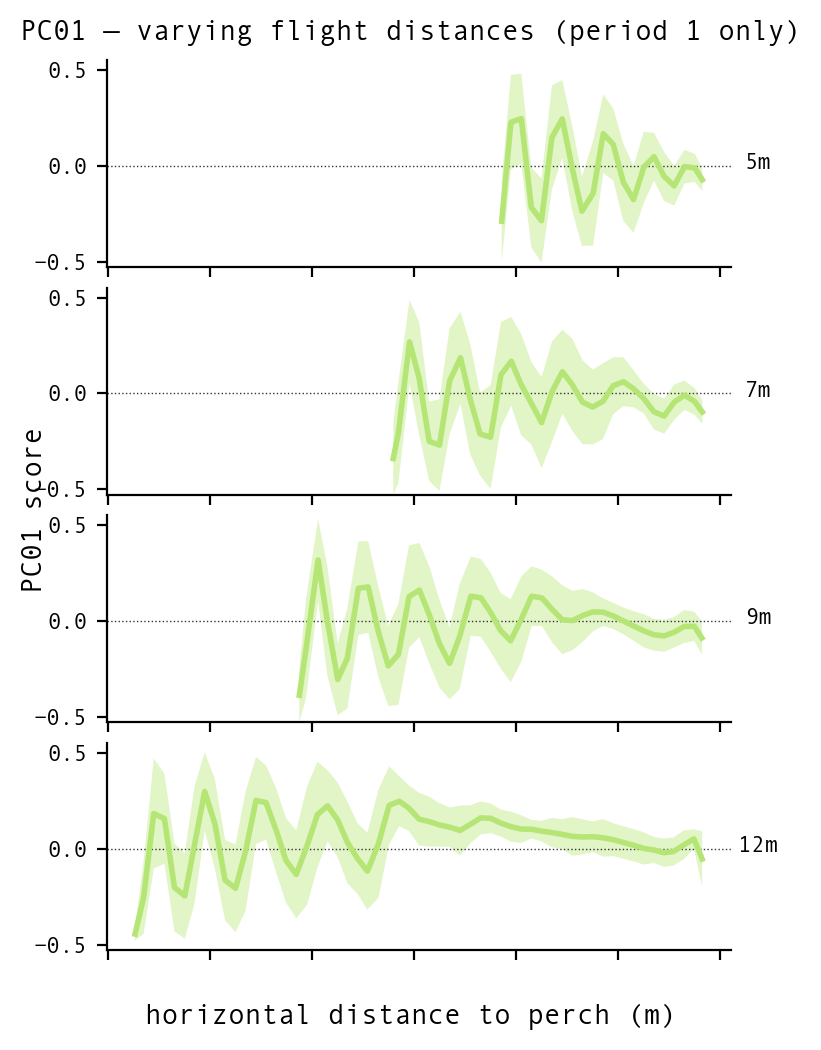

Saved: ../../figures/supplementary/S10_scores_by_distance_PC02.pdf


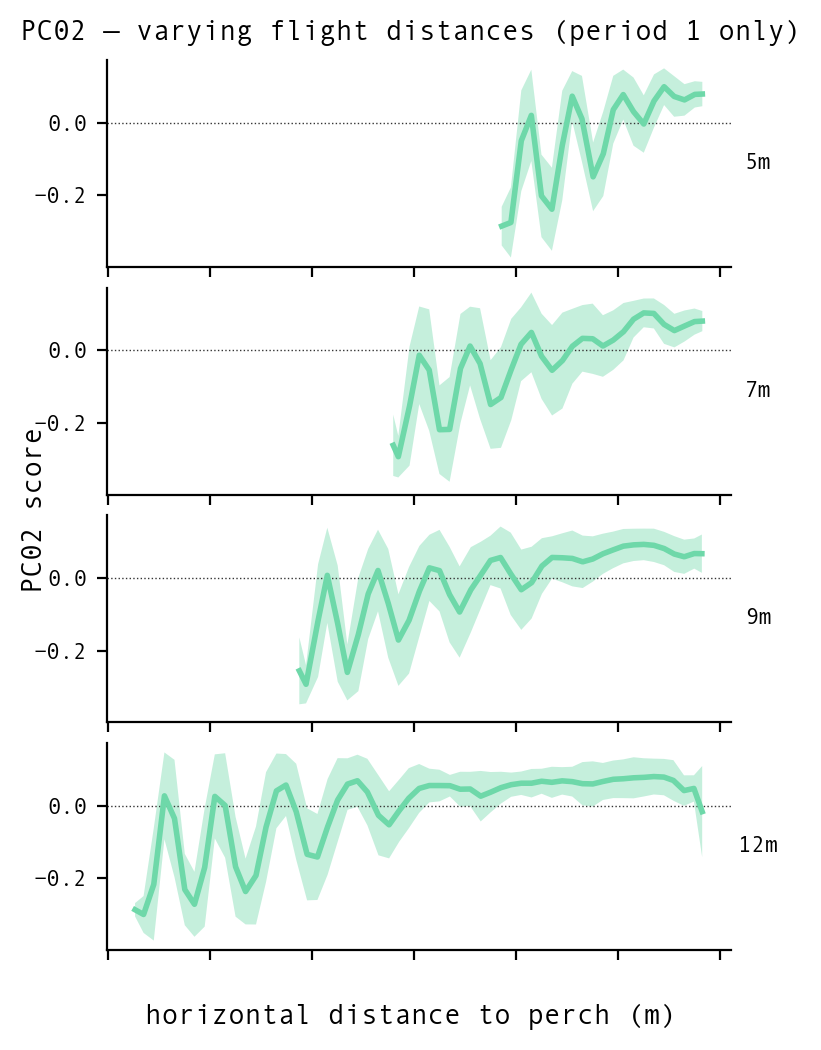

Saved: ../../figures/supplementary/S10_scores_by_distance_PC03.pdf


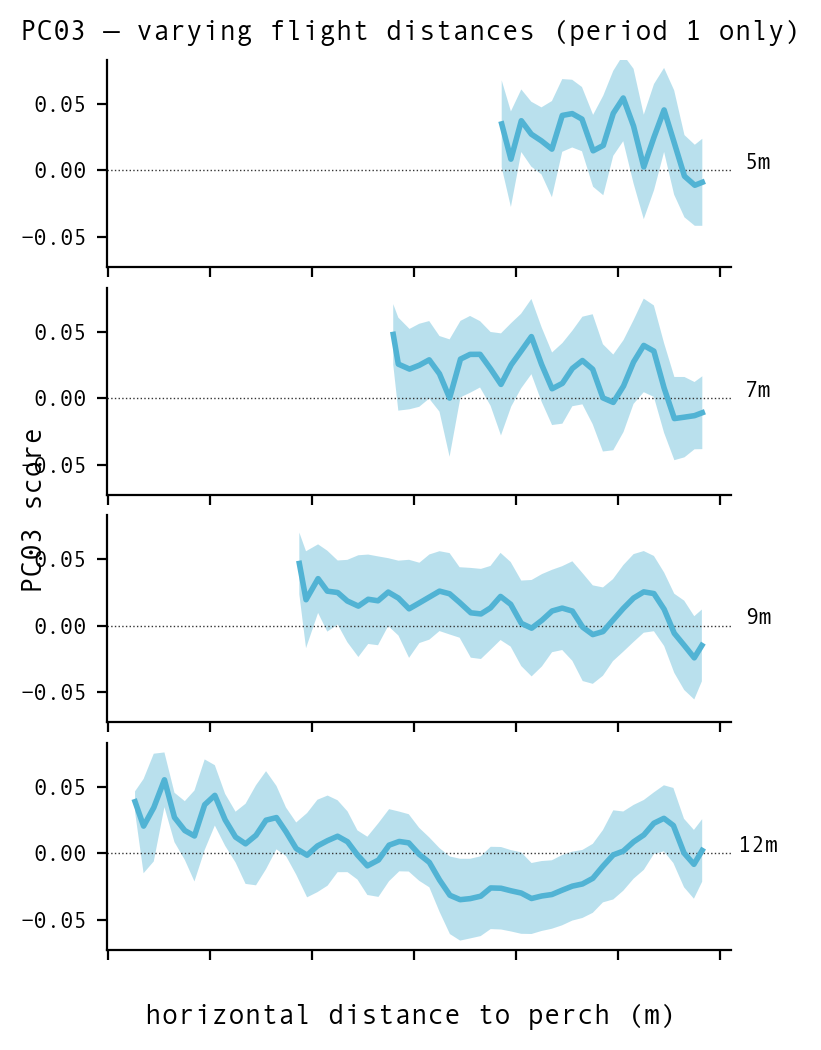

Saved: ../../figures/supplementary/S10_scores_by_distance_PC04.pdf


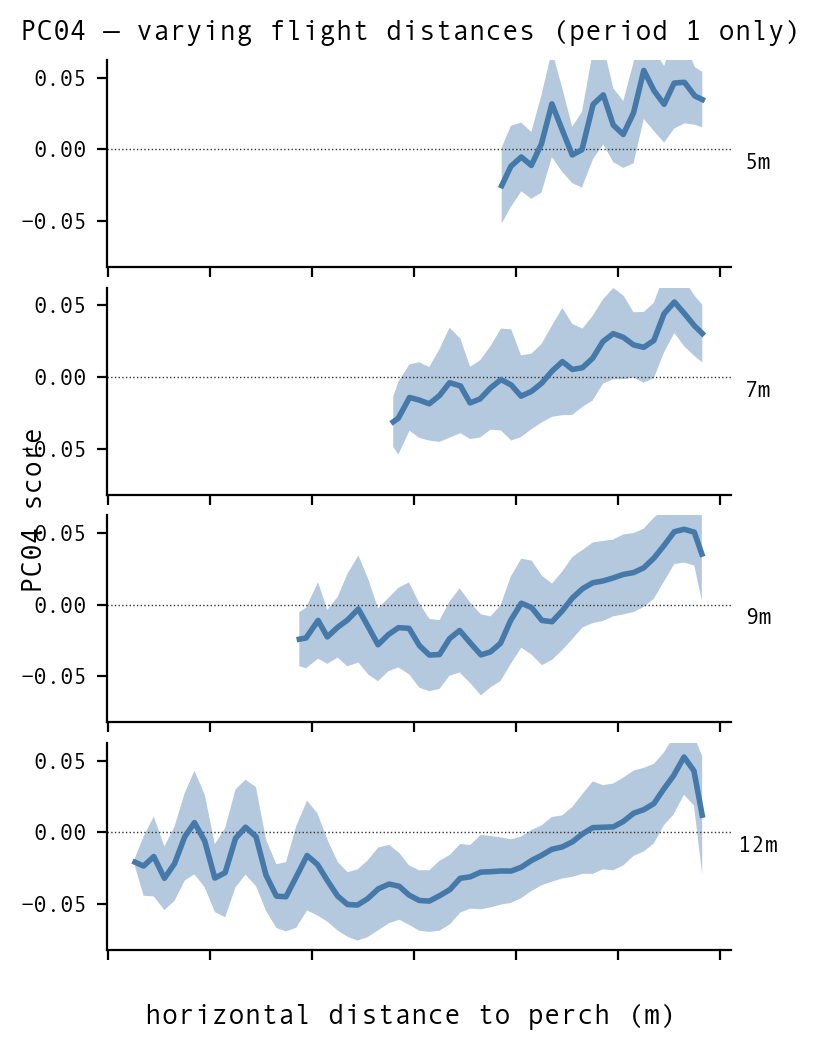

In [6]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_multi_distance(scores_df, pc, obstacle=0, year=2017)
    plt.suptitle(f"{pc} — varying flight distances (period 1 only)", fontsize=10, y=1.02)
    save_figure(fig, f'{CONFIG["fig_dir"]}/S10_scores_by_distance_{pc}.pdf')
    plt.show()

### Summary of §10.2

**Modes 1–2 (wing lifting and spreading):** Wingbeat cycles are visible in the first few metres of flight. Flapping amplitude decreases with each successive wingbeat while span increases. For longer flights (9 m, 12 m), hawks transition to a glide with maximum spread and steadily lowering wings to neutral. For shorter flights (5 m, 7 m), wingspan steadily increases over the flapping cycles into landing. A small peak in wing lifting occurs in the 1 m before landing.

**Mode 3 (wing sweep):** Sweep oscillates during wingbeat cycles. During 9 m glides, forward-and-backward oscillations continue; in 12 m glides, the wings are more swept back at the glide transition then steadily sweep forwards. Across all distances, a peak of positive (forward) sweep occurs approximately 1.5 m before the perch.

**Mode 4 (tail spreading):** Oscillates with wingbeat cycles and increases on approach to the perch. At landing, tail spread reaches its maximum and then decreases with foot contact (approximately 0.3 m before the perch). At the transition to gliding in the longer flights, tail spread is minimal and then increases through the glide. Tail spreading coincides with the hawks pitching up (see Notebook 03, "Projection to Symmetrical Components").

**Mode 5 (counter-pitching):** The tail lowers whilst the wings pitch in the opposite direction but with smaller magnitude. During flapping, wing pitch oscillates but is on average negative (trailing edge above leading edge). In gliding, wing pitch increases and at maximum — approximately 1.5 m before the perch — the leading and trailing edges are at the same height in the body coordinate space. A sudden reduction in wing pitch occurs approximately 1 m before the perch during rapid whole-body pitch-up. Combined with wings sweeping forward briefly, these shape changes resemble a "shrug" manoeuvre, visible in videos of landing hawks and a steppe eagle (Carruthers et al. 2007). Before this point the covert feathers flip up under stall conditions but suddenly flatten afterwards, suggesting this manoeuvre could be involved with flow reattachment.

## Obstacle Versus Control Flights

> **§10.3**

Data from experimental period 2: 9 m flights with and without an obstacle at the midpoint. The §10.1 overview showed which modes are perturbed by the obstacle; here we examine modes 1–4 in detail, split by individual hawk, to see how each bird's obstacle-avoidance trajectory differs from its own control flights.

### Time traces — obstacle vs control per hawk

Saved: ../../figures/supplementary/S10_scores_obstacle_control_PC01.pdf


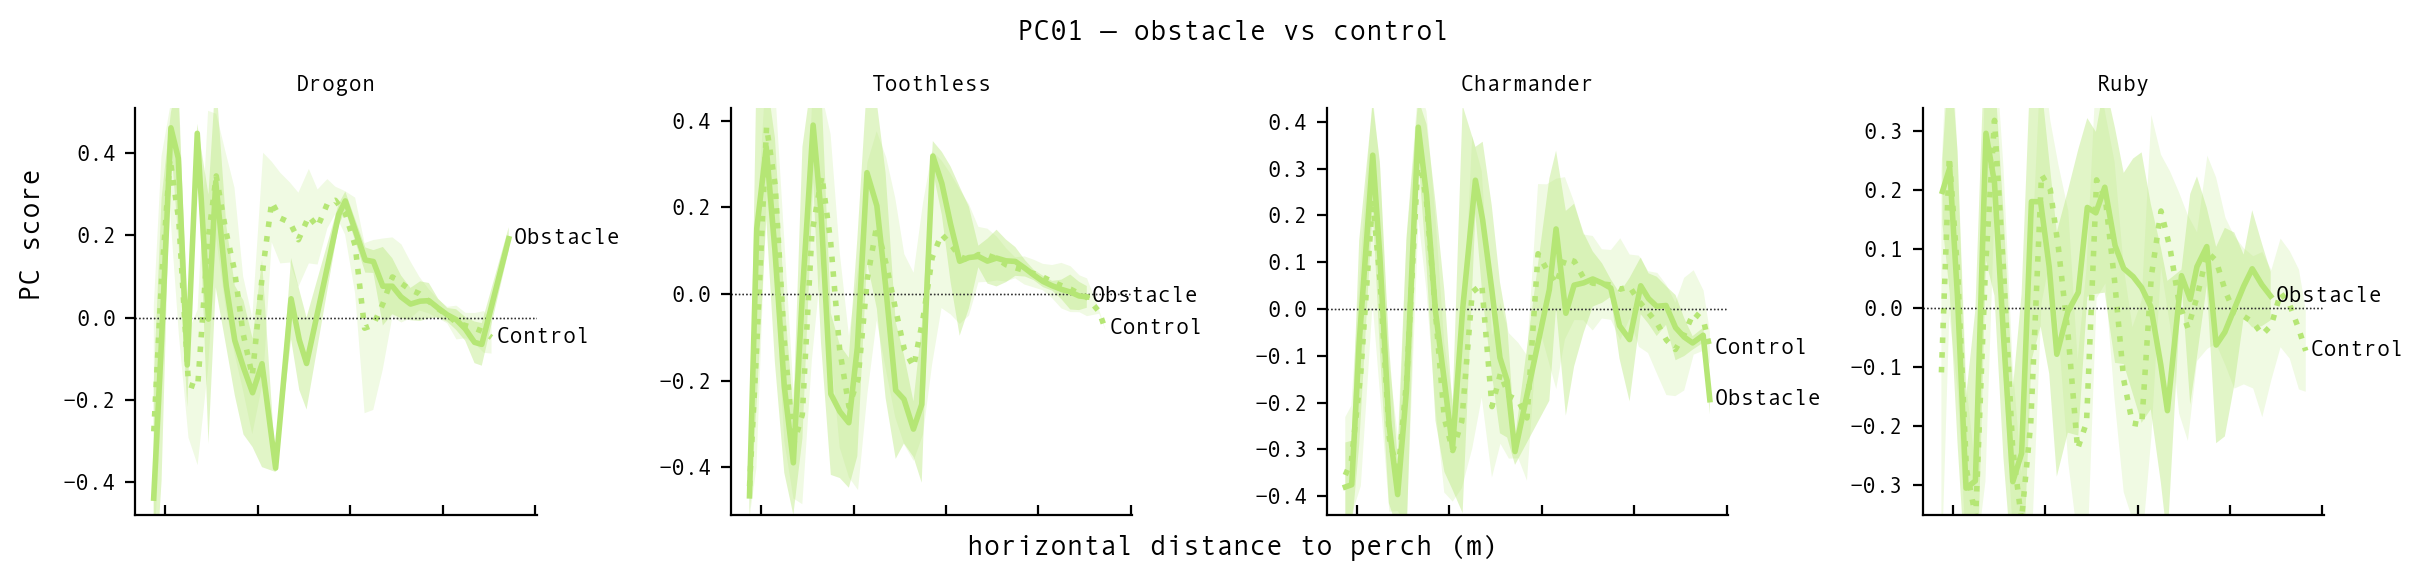

Saved: ../../figures/supplementary/S10_scores_obstacle_control_PC02.pdf


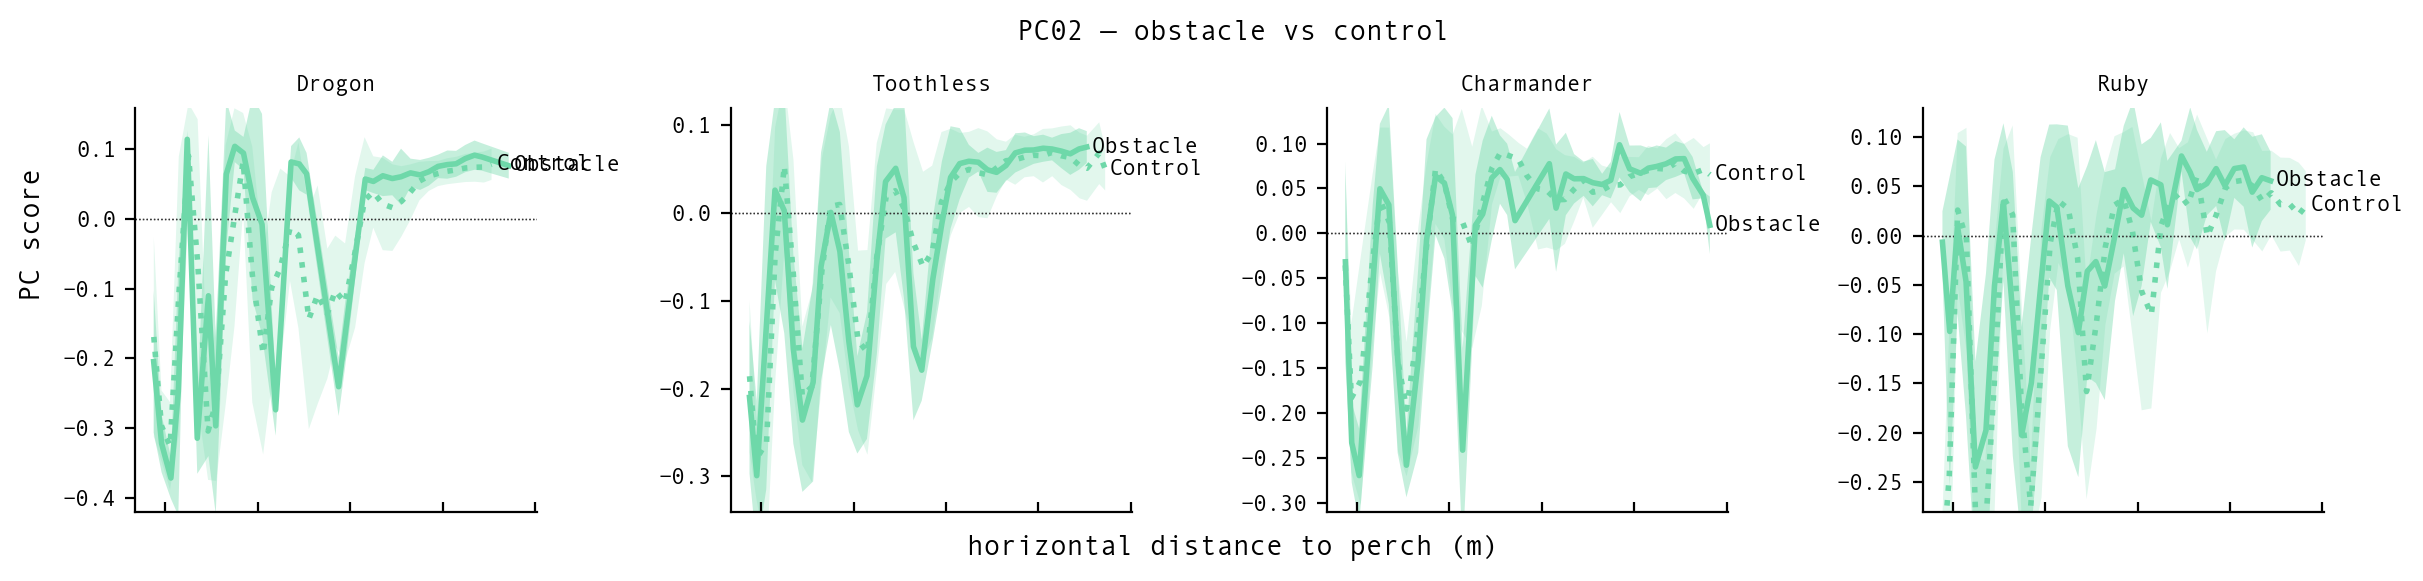

Saved: ../../figures/supplementary/S10_scores_obstacle_control_PC03.pdf


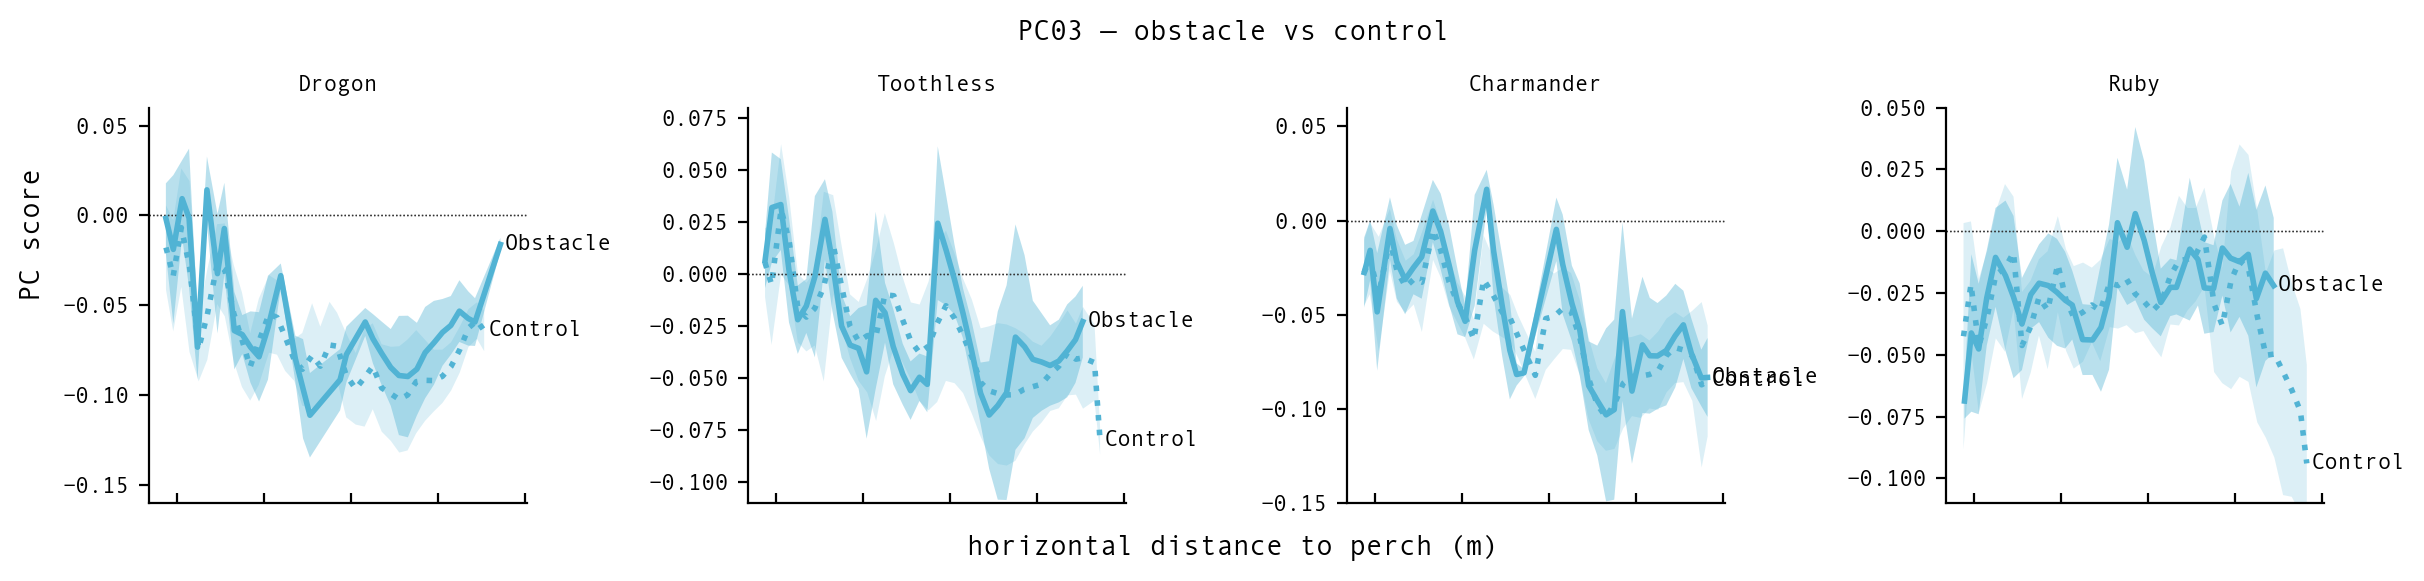

Saved: ../../figures/supplementary/S10_scores_obstacle_control_PC04.pdf


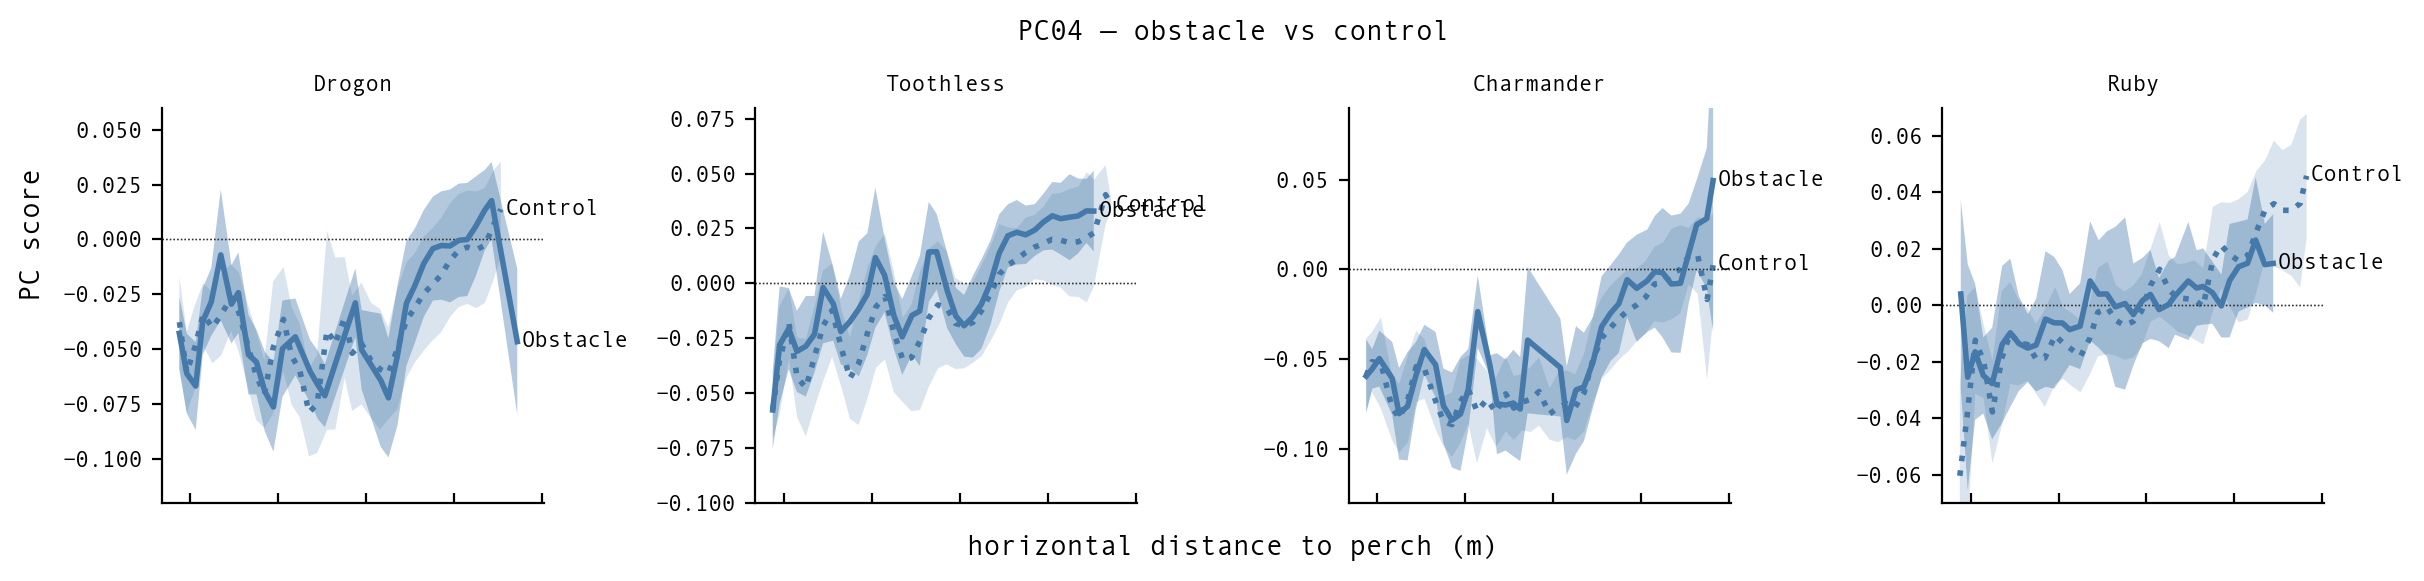

In [7]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_obstacle_control(scores_df, pc)
    plt.suptitle(f"{pc} — obstacle vs control", fontsize=10, y=1.05)
    save_figure(fig, f'{CONFIG["fig_dir"]}/S10_scores_obstacle_control_{pc}.pdf')
    plt.show()

### Observations from §10.3

- A sudden increase and decrease in **wing sweep** (Mode 3) is visible around the obstacle at the midpoint.
- There is a new, highly variable decrease in **collective pitching** (Mode 8) — the tail drops as the wings pitch up.
- A decrease and increase in **hand-wing sweep** (Mode 9) also appears around the obstacle.

**Wingbeat frequency caveat:** Between individuals, wingbeat frequency differs, which affects the binned means. More advanced methods that decompose the time-series dynamics of morphing flight would be required to compare across different flights and individuals with different wingbeat frequencies, but this is beyond the scope of this analysis.

## Individual Variation and Context Effects

> **§10.4**

Individual variation in morphing is high, as is the timing of manoeuvres. Below we examine each hawk's score trajectories under three conditions: control (no obstacle, no weight), with added weight (IMU backpack), and naive versus experienced.

The within-individual standard deviation is markedly smaller than the across-individual variation, demonstrating that each hawk uses a consistent personal morphing strategy. This consistency holds across modes and conditions — the morphing modes therefore capture repeatable, individual-level patterns of wing and tail use.

### Per-hawk scores — control flights

Saved: ../../figures/supplementary/S10_scores_per_hawk_PC01.pdf


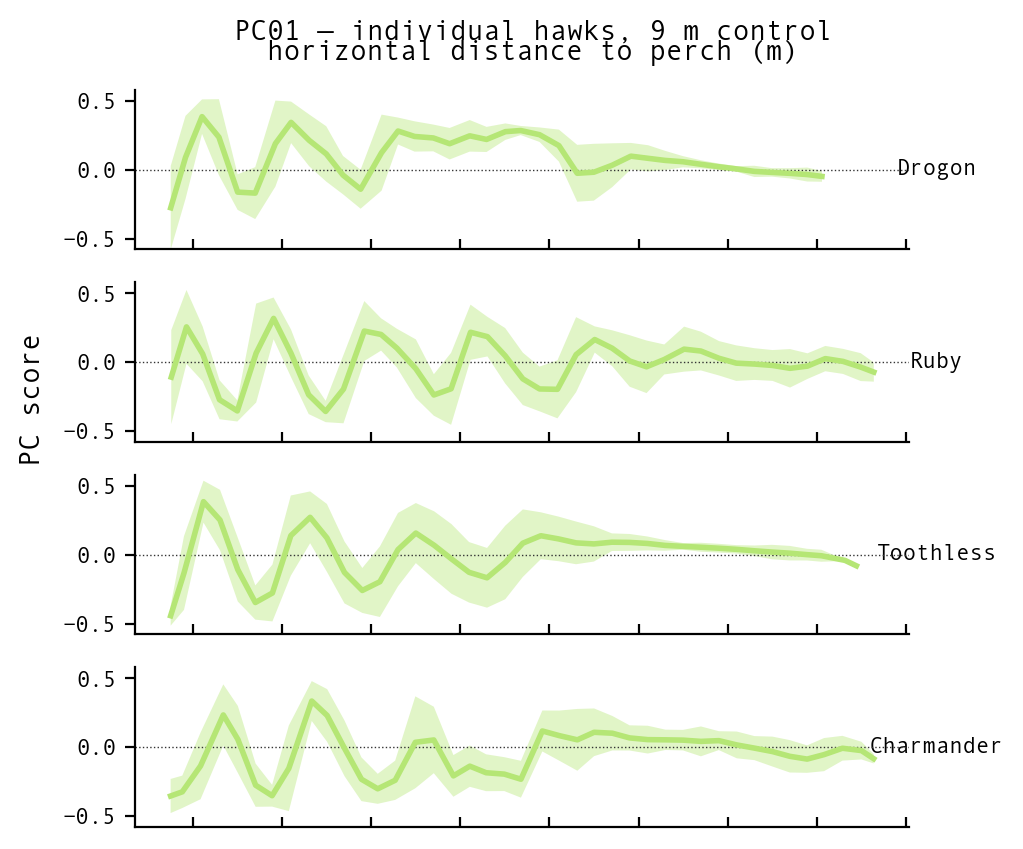

Saved: ../../figures/supplementary/S10_scores_per_hawk_PC02.pdf


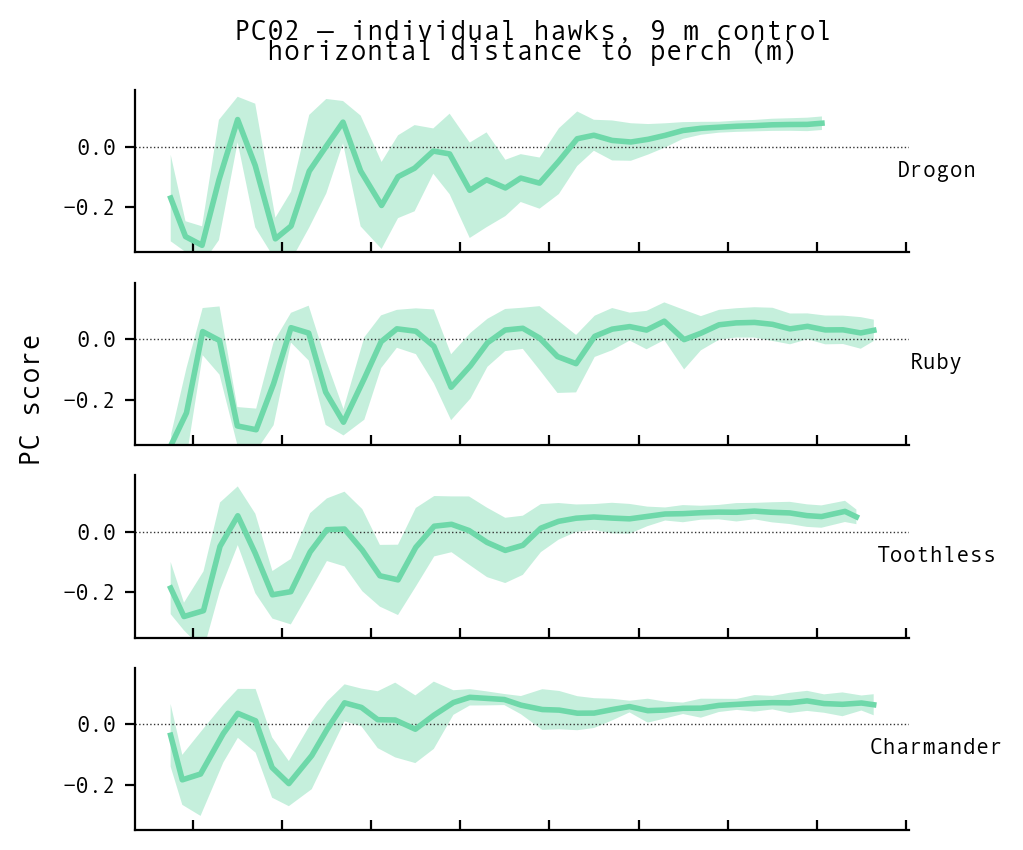

Saved: ../../figures/supplementary/S10_scores_per_hawk_PC03.pdf


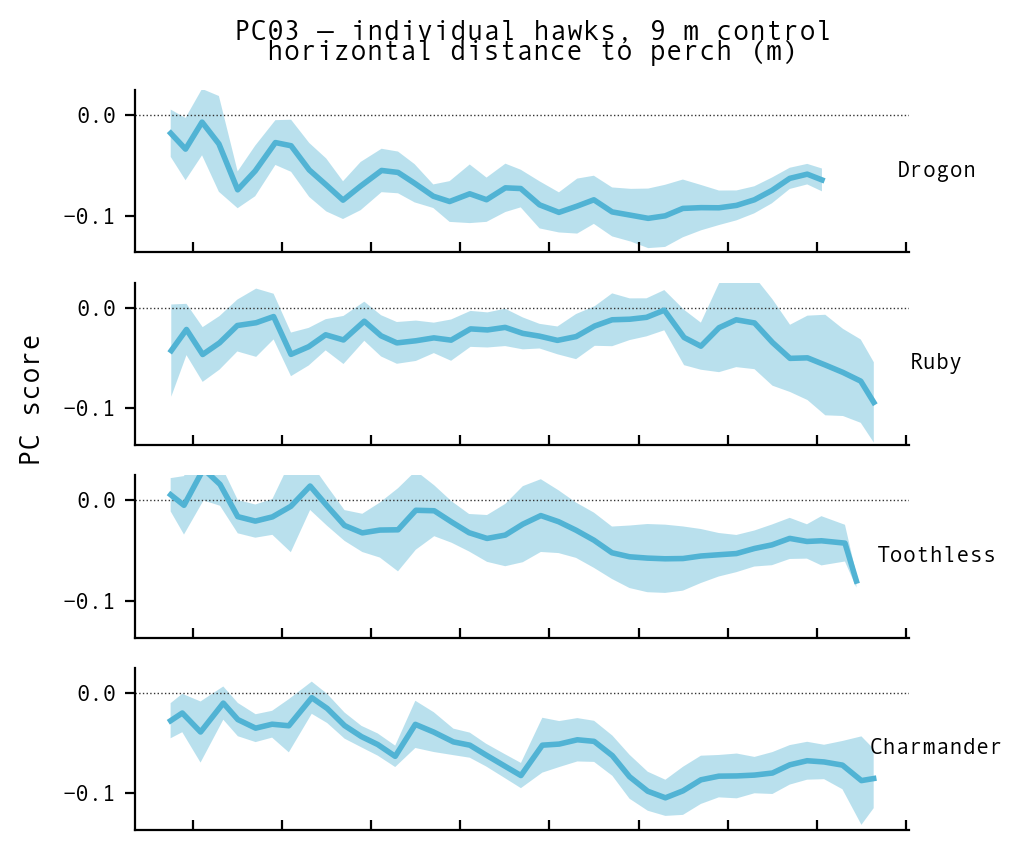

Saved: ../../figures/supplementary/S10_scores_per_hawk_PC04.pdf


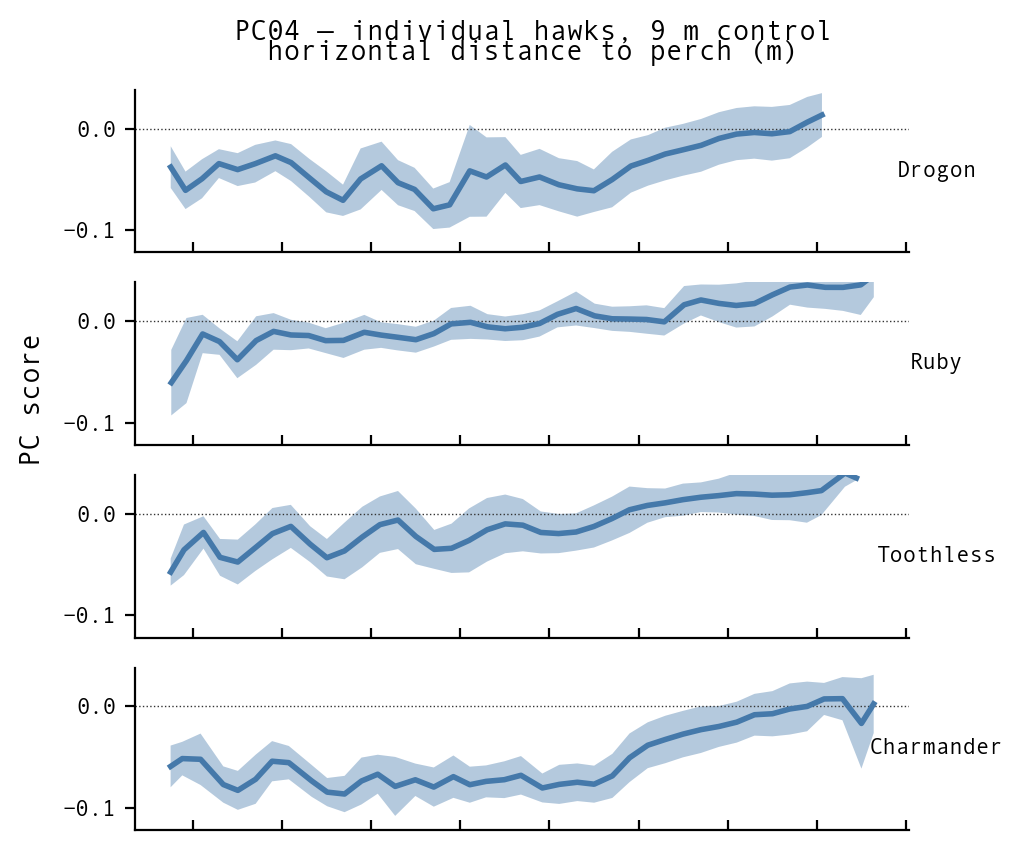

In [8]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_multi_bird(scores_df, pc, perchDist=9, obstacle=0, year=2020)
    plt.suptitle(f"{pc} — individual hawks, 9 m control", fontsize=10, y=1.05)
    save_figure(fig, f'{CONFIG["fig_dir"]}/S10_scores_per_hawk_{pc}.pdf')
    plt.show()

**Interpretation.** Individual hawks show highly consistent morphing strategies that persist across the full flight trajectory. Wing sweep (Mode 3) best illustrates individual signatures: Drogon maintains the most swept-back posture throughout the flight (mean ≈ −0.09 in the approach phase), while Ruby stays closest to neutral (≈ −0.02). These between-hawk differences exceed the within-hawk variability at every distance bin. Tail spreading (Mode 4) is similarly individual-specific — Charmander's tail remains the most negative (least spread) across all distances, while Ruby's is consistently the most positive. The dominant modes (1–2) show more inter-individual similarity in trajectory shape, though individual wingbeat phasing is visible in the flapping region. By 2 m from the perch, all hawks converge to similar postures regardless of individual strategy.

### Effect of added weight

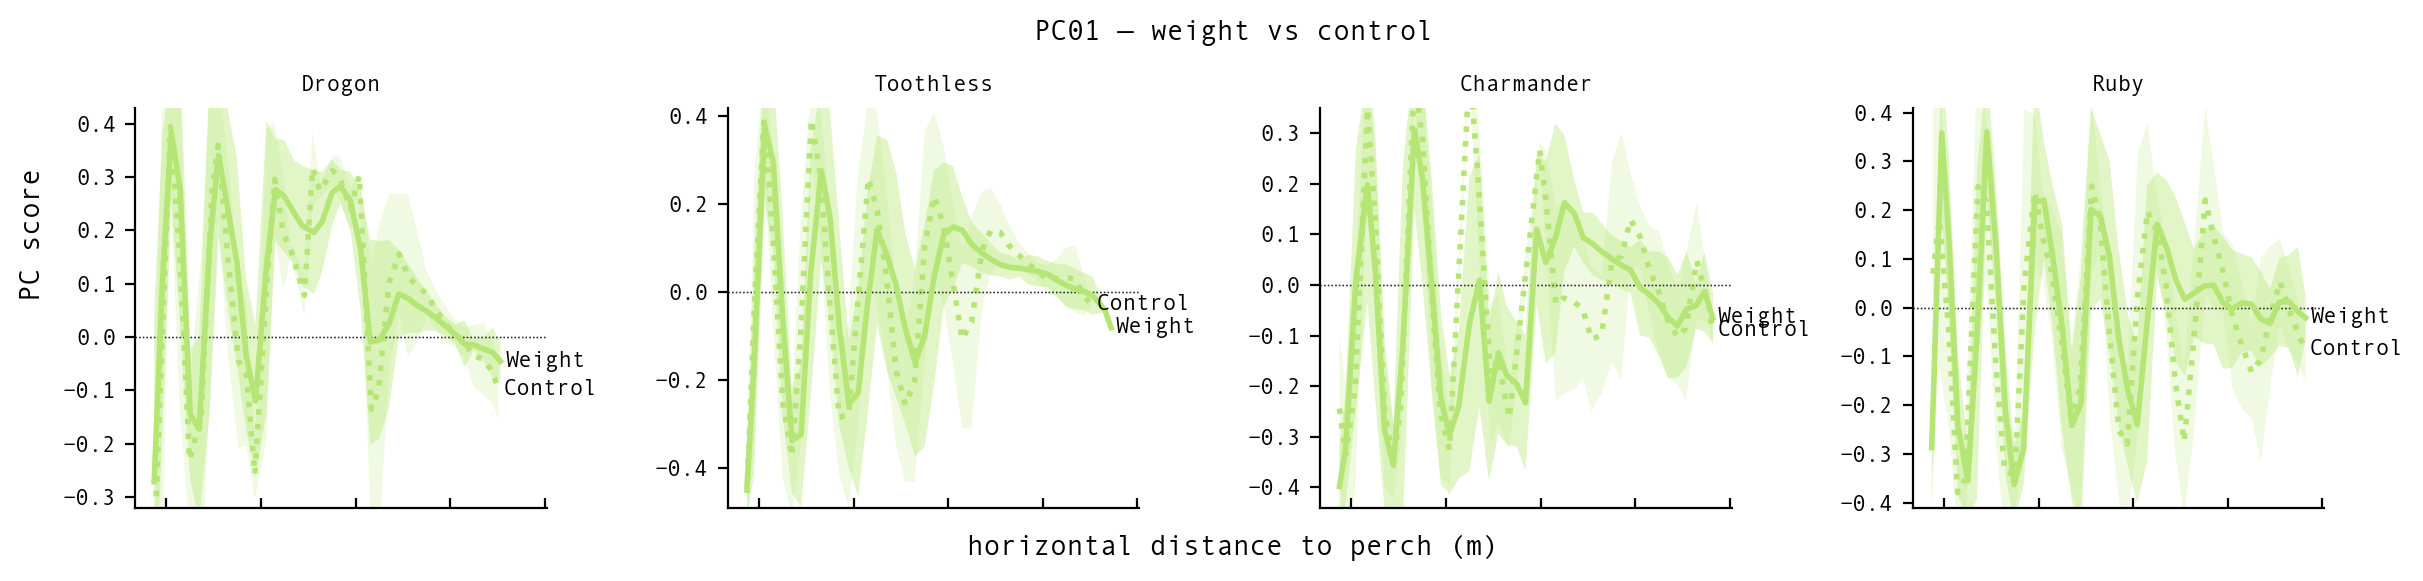

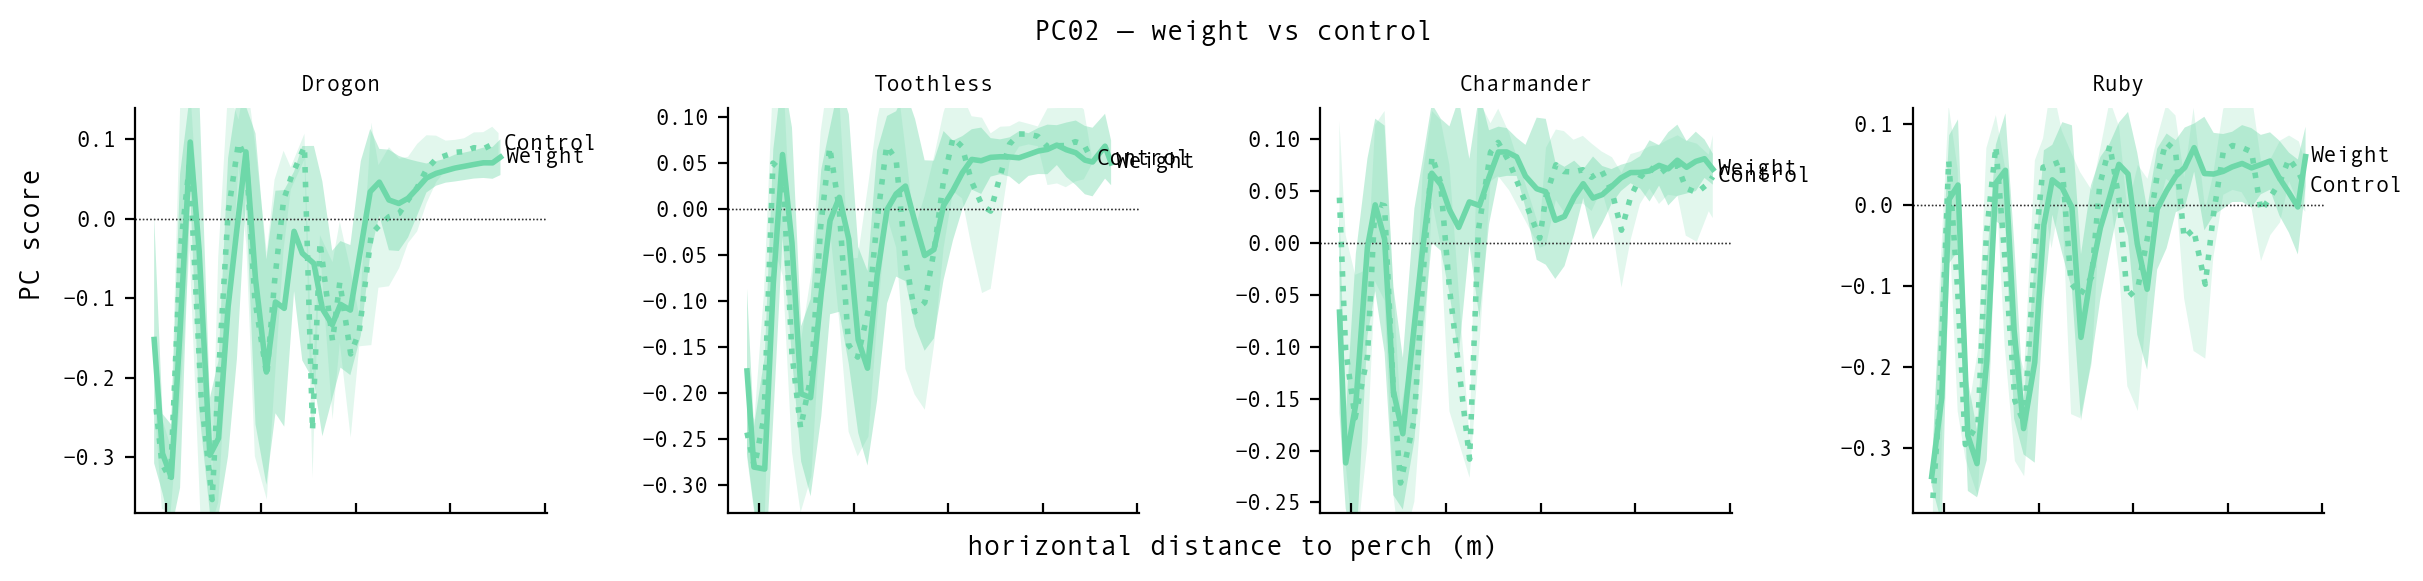

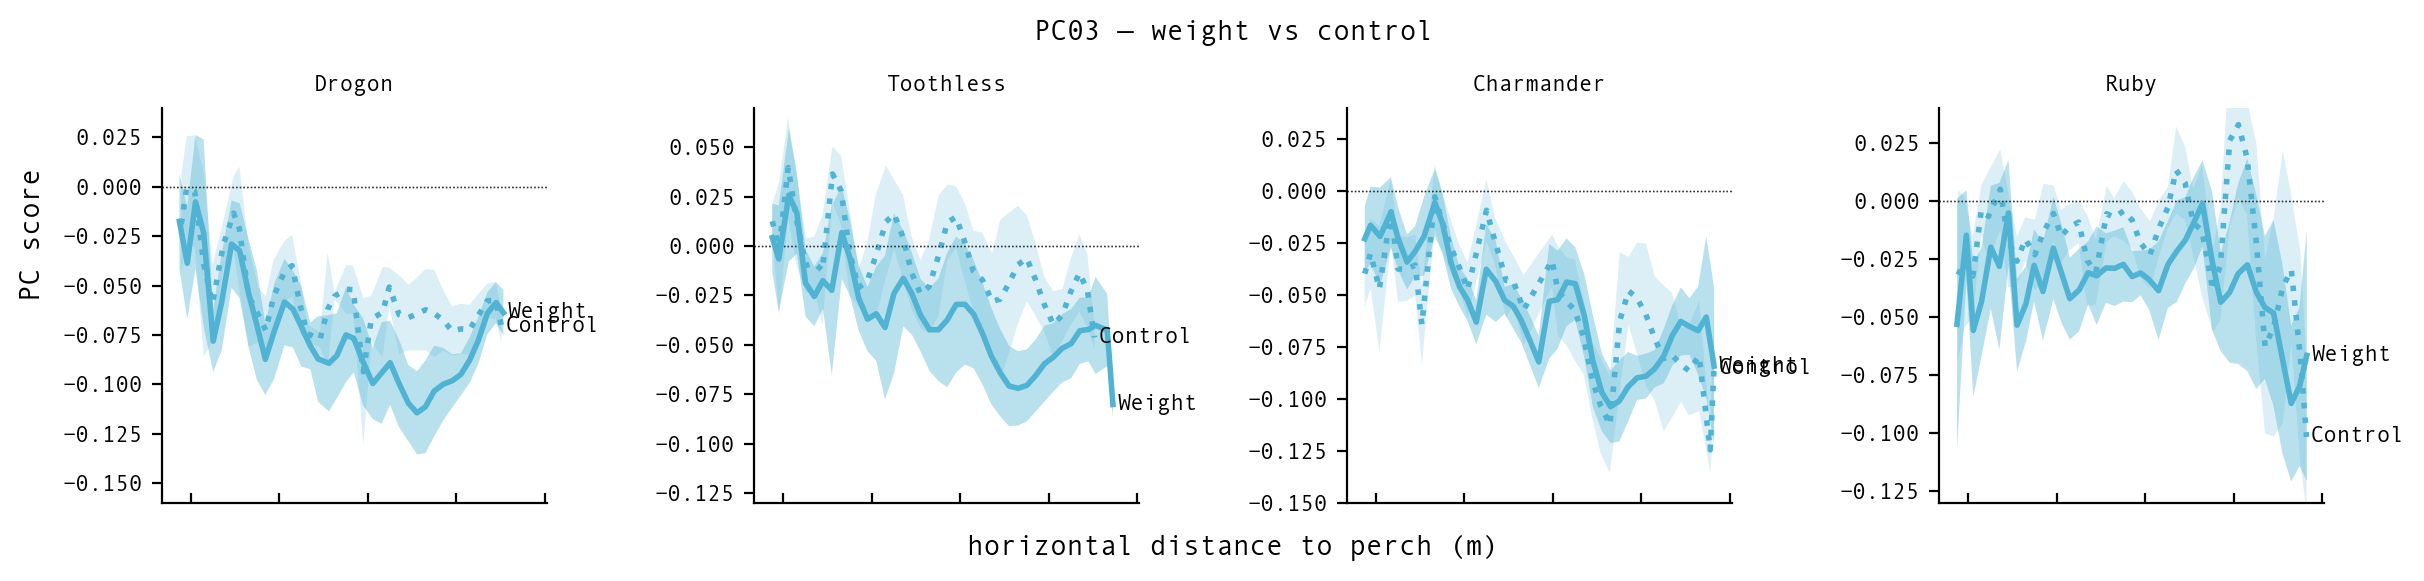

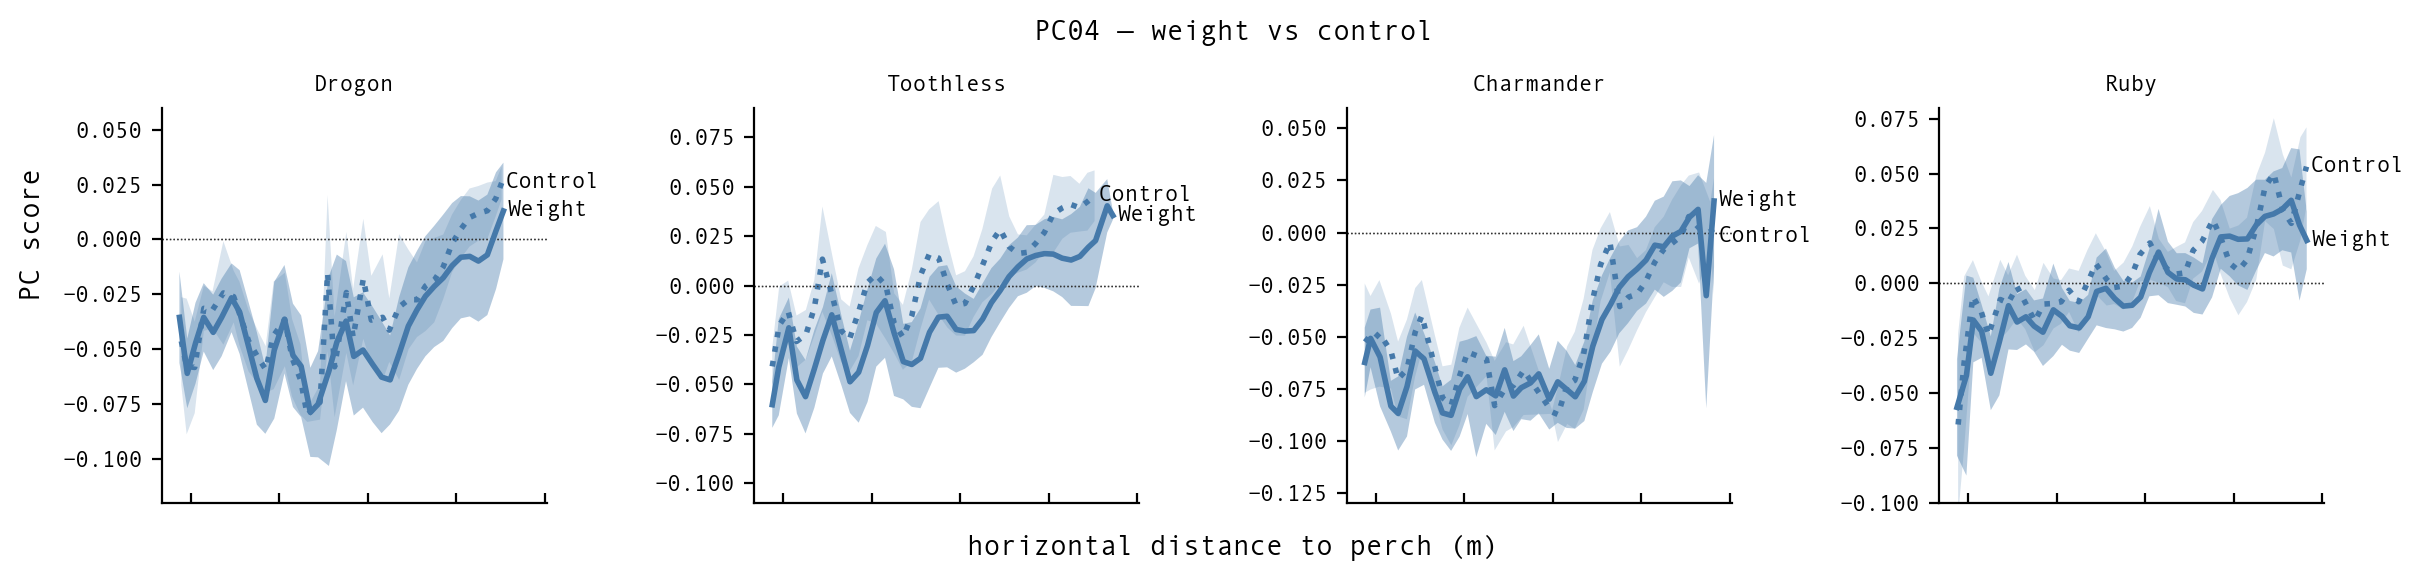

In [9]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_weight_control(scores_df, pc)
    plt.suptitle(f"{pc} — weight vs control", fontsize=10, y=1.05)
    plt.show()

**Interpretation.** Added weight (IMU backpack) produces modest but consistent shifts in sweep and tail-spread trajectories. Wing sweep (Mode 3) becomes less negative with weight (difference ≈ +0.02 to +0.05 across the approach), meaning the wings are swept slightly less far back — possibly a compensatory posture adjustment. Tail spreading (Mode 4) also shifts positive with weight (difference ≈ +0.01 to +0.03), indicating a slightly more spread tail throughout the flight. Wing lifting (Mode 1) differences are dominated by wingbeat phase shifts rather than a consistent directional effect, suggesting flapping kinematics are not systematically altered by the added mass. The weight effects are small relative to individual variation (§10.3a) but are consistent in sign across the full trajectory.

### Naive vs experienced hawks

Two hawks (Drogon, Toothless) were recorded both as naive juveniles (2017) and as experienced adults (2020). The dotted line shows naive flights; the solid line shows experienced flights.

Saved: ../../figures/supplementary/S10_scores_naive_experienced_PC01.pdf


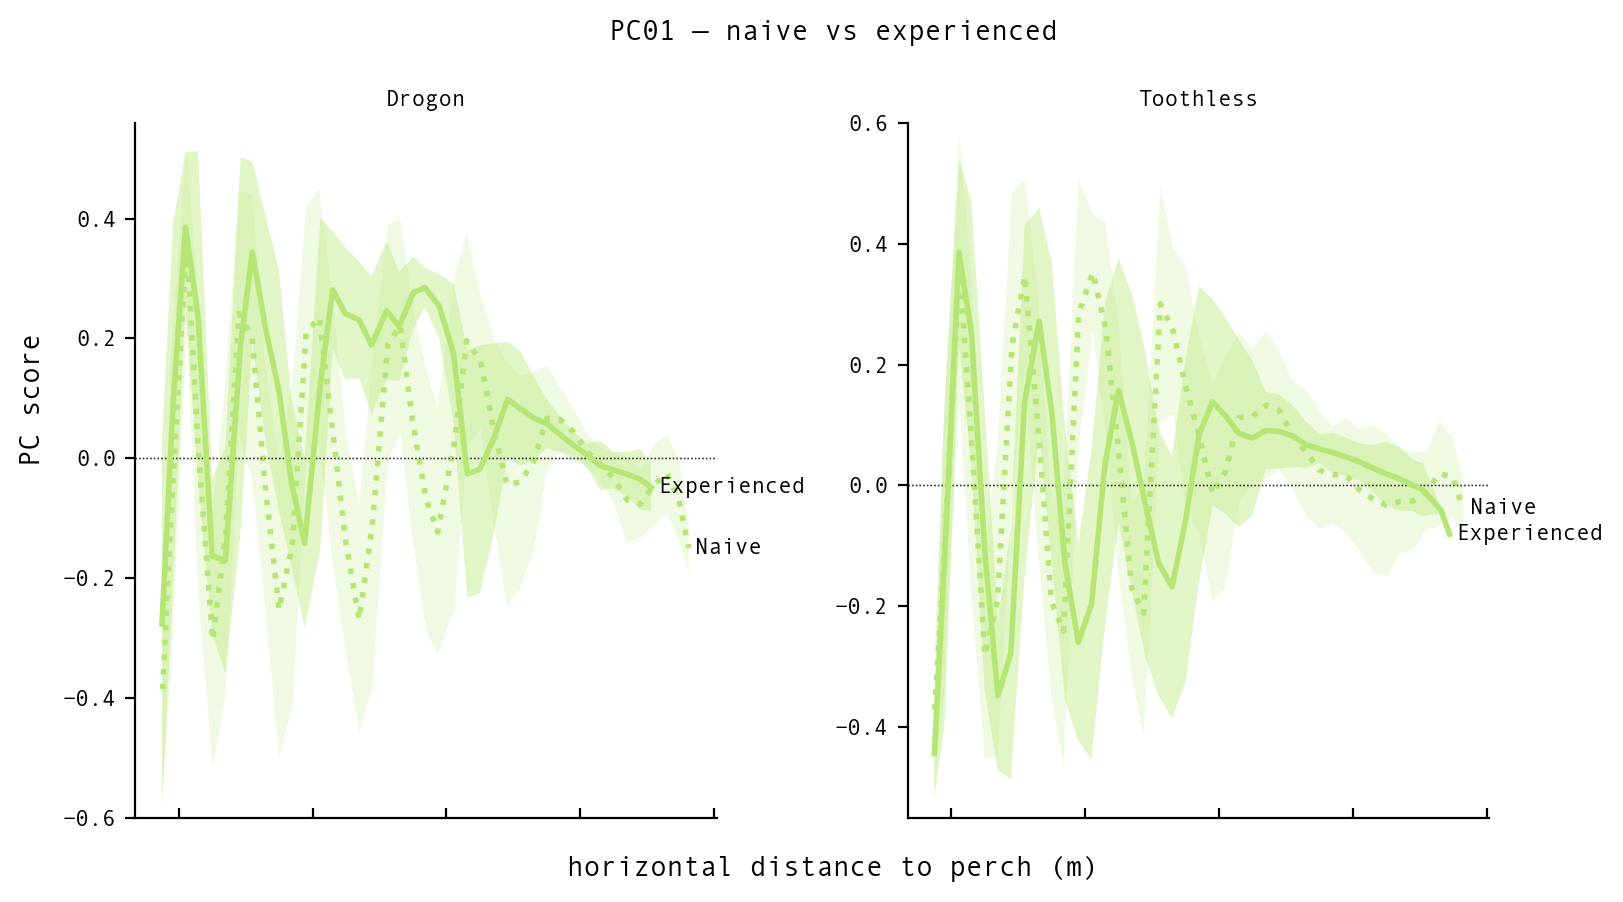

Saved: ../../figures/supplementary/S10_scores_naive_experienced_PC02.pdf


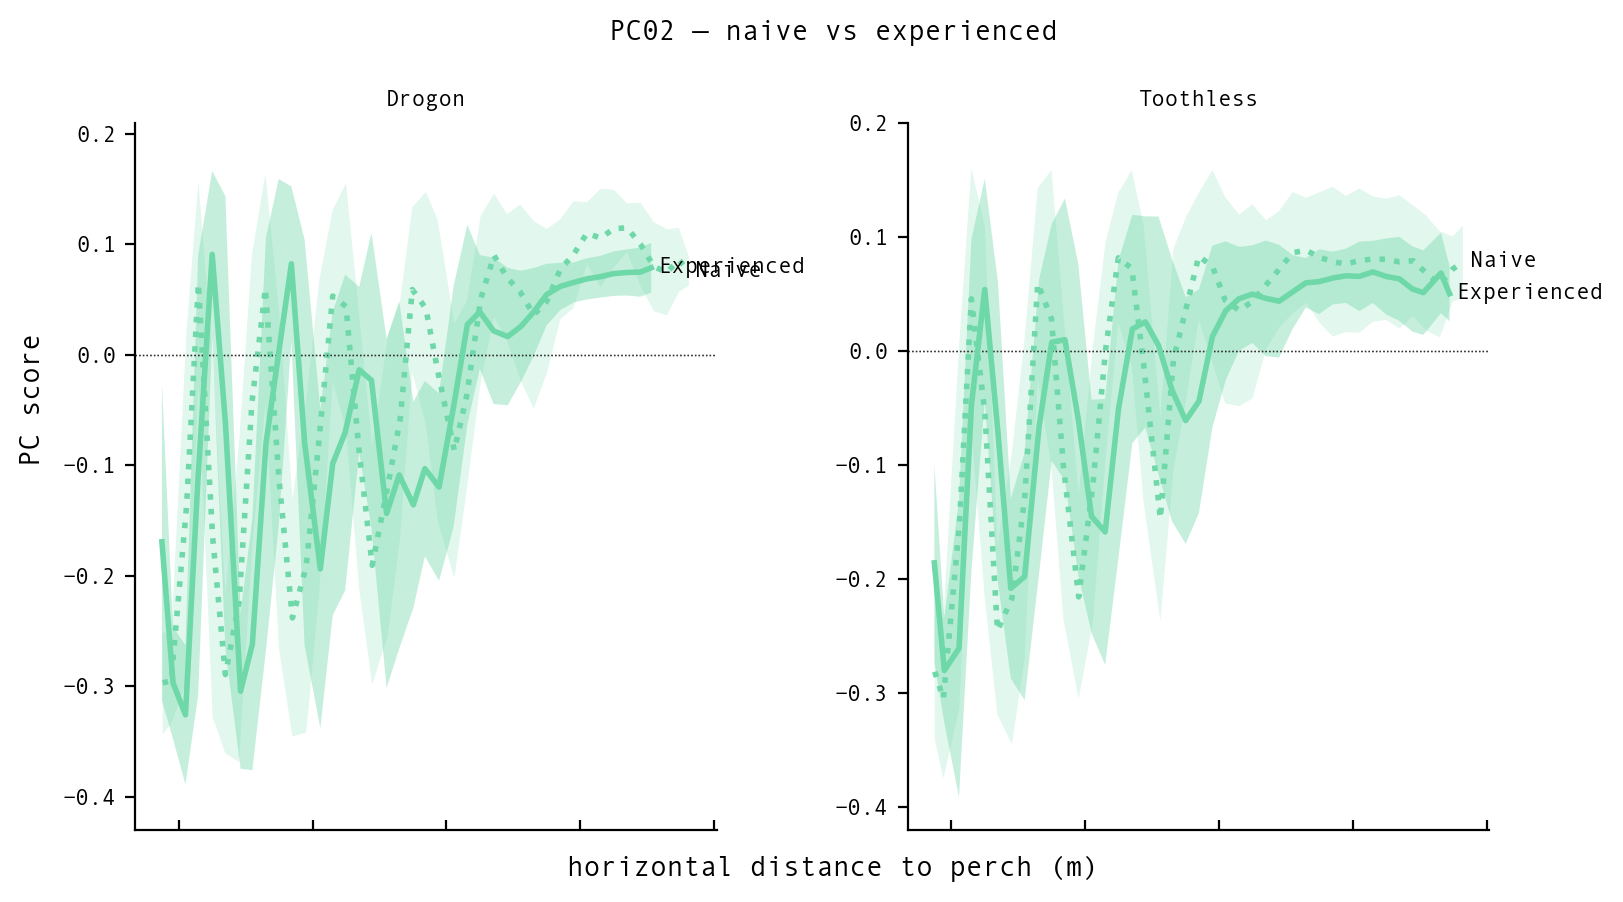

Saved: ../../figures/supplementary/S10_scores_naive_experienced_PC03.pdf


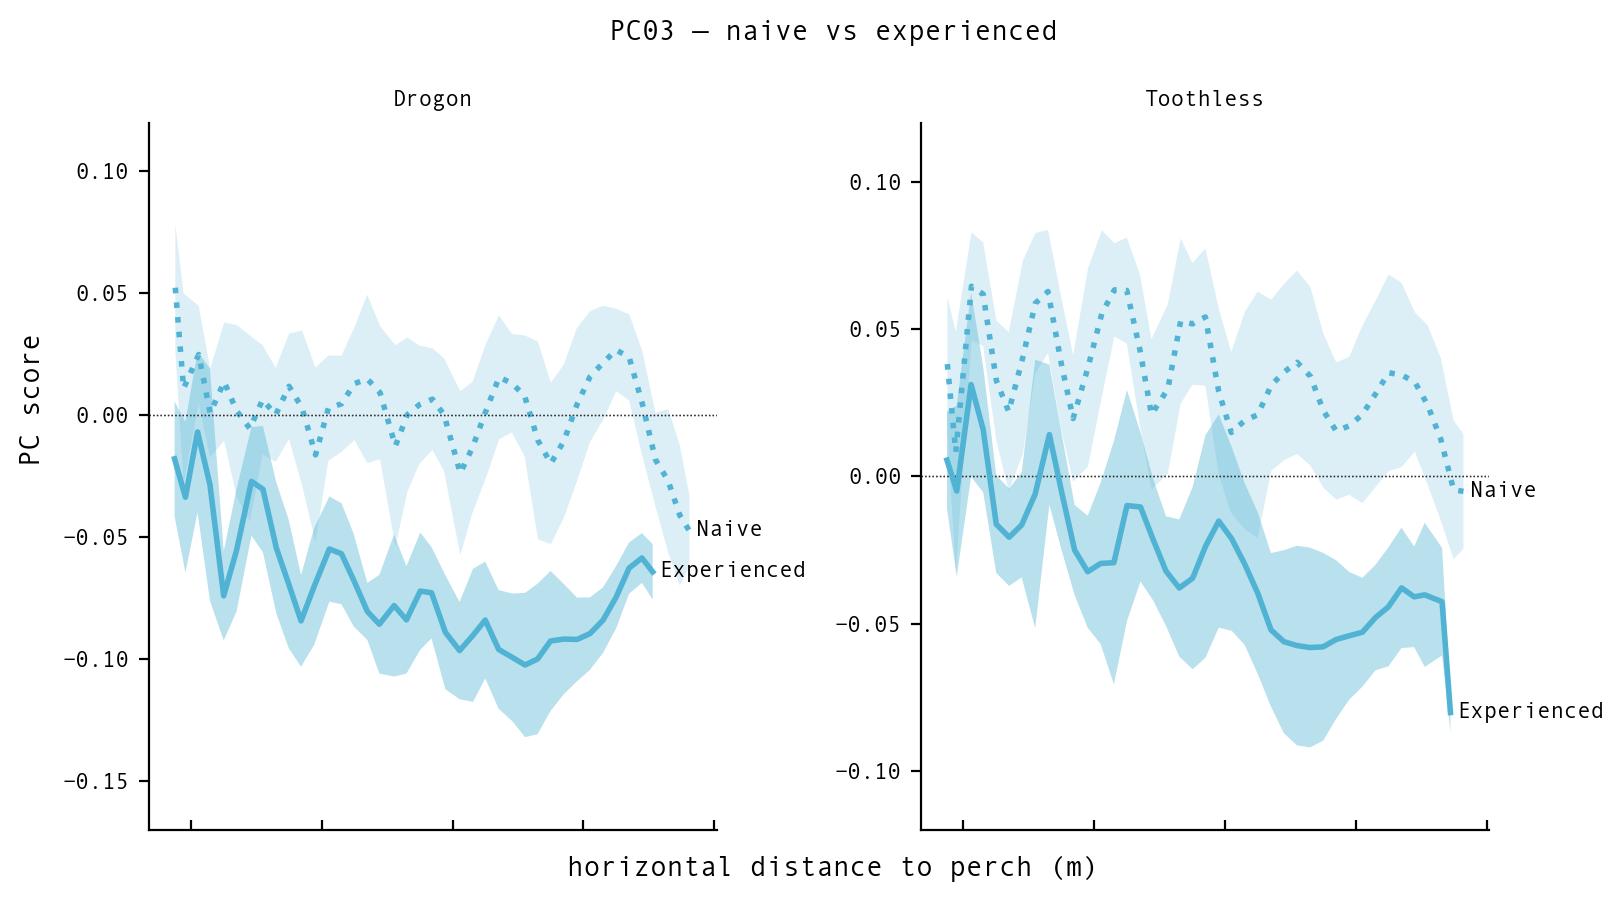

Saved: ../../figures/supplementary/S10_scores_naive_experienced_PC04.pdf


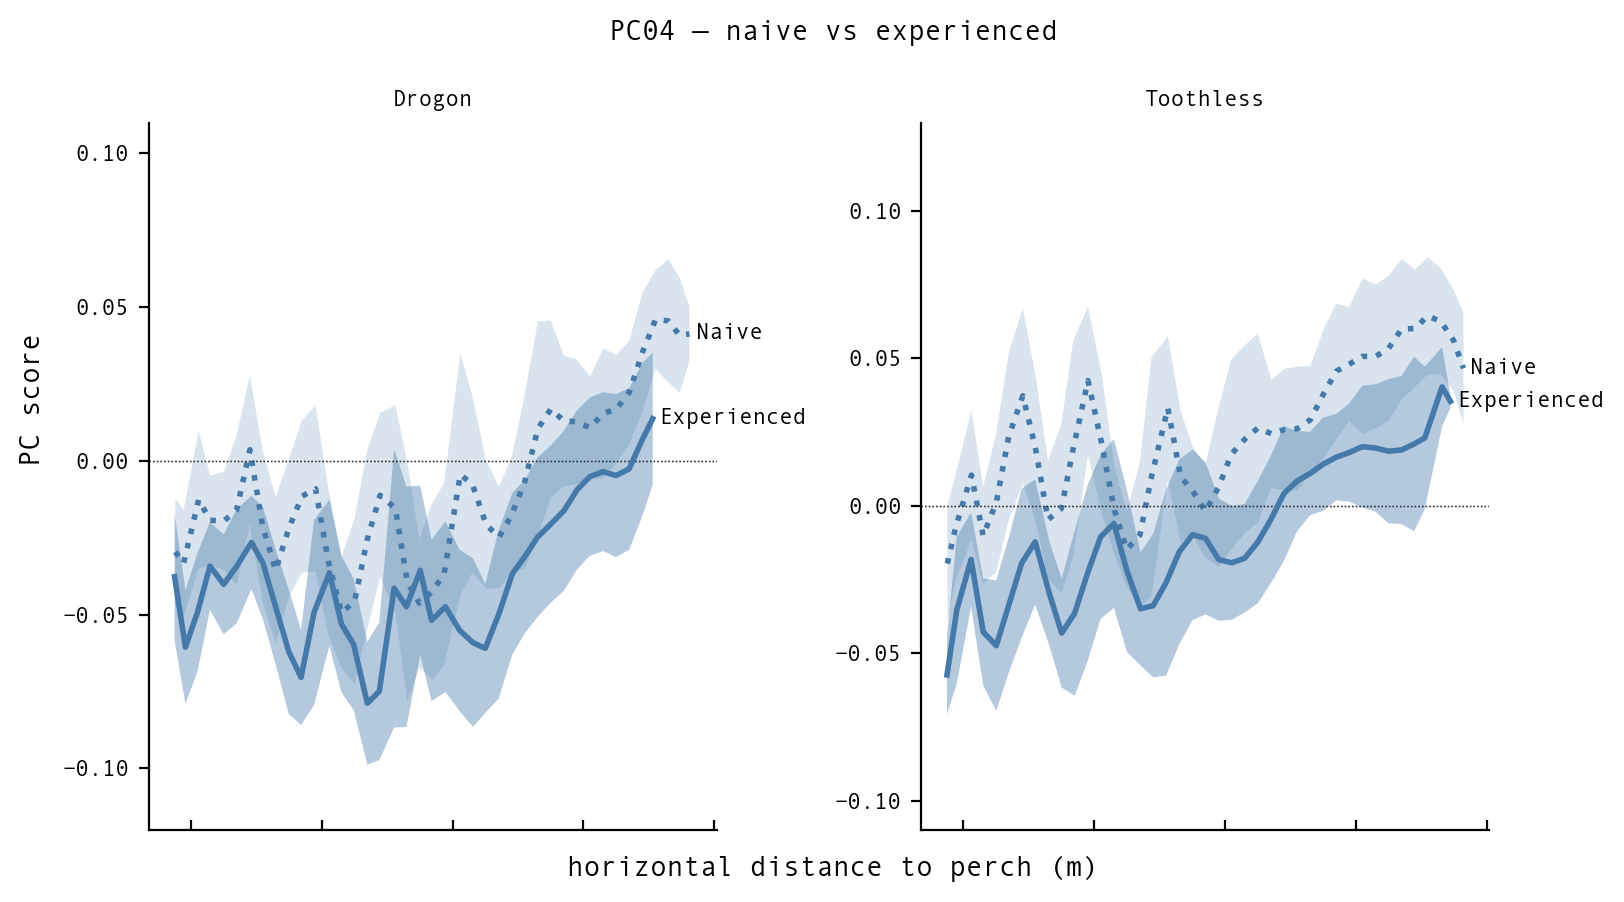

In [10]:
plt.close("all")
for pc in ["PC01", "PC02", "PC03", "PC04"]:
    fig, axes = plot_score_naive_control(scores_df, pc,
                                         hawkname_list=("Drogon", "Toothless"))
    plt.suptitle(f"{pc} — naive vs experienced", fontsize=10, y=1.05)
    save_figure(fig, f'{CONFIG["fig_dir"]}/S10_scores_naive_experienced_{pc}.pdf')
    plt.show()

**Interpretation.** The largest experience effect is in wing sweep (Mode 3): both hawks shift strongly negative across the entire trajectory as experienced adults (Drogon: Δ ≈ −0.06 to −0.11; Toothless: Δ ≈ −0.04 to −0.09 at every distance bin). This indicates that experienced hawks adopt a consistently more swept-back wing posture throughout the flight — a systematic strategy shift rather than a localised adjustment. Tail spreading (Mode 4) also shifts negative with experience for both hawks (Δ ≈ −0.02 to −0.06), suggesting a less spread tail during the approach phase. Wing lifting (Mode 1) differences are dominated by wingbeat phase shifts — the oscillations have similar amplitude but different timing between years, making mean comparisons misleading for this mode. This complements the symmetry analysis (Notebook 10), which showed that bilateral coordination also tightens with experience; here we see that the *mean strategy* itself changes substantially.

## Summary

The morphing mode scores reveal structured temporal dynamics across flight contexts:

- **Wingbeat cycles** are clearly visible in Modes 1–4 during flapping, with amplitude decreasing and span increasing as the hawk accelerates.
- **Flapping-to-gliding transitions** occur in longer flights (9–12 m), with maximum wingspan during the glide and gradual reductions on approach.
- **Mode-specific landmarks:** A forward-sweep peak (~1.5 m before perch), maximum tail spread at landing (~0.3 m), and a counter-pitching "shrug" (~1 m) are consistent across flight distances.
- **Obstacle avoidance** introduces characteristic perturbations in sweep, collective pitching, and hand-wing shape near the midpoint obstacle.
- **Individual consistency** is high — within-hawk variation is substantially smaller than between-hawk variation across all conditions.
- **Experience effects** show that juvenile hawks use qualitatively similar but less consistent morphing patterns compared to the same individuals recorded as experienced adults.

**Note on mode ordering:** Collective pitching (PC08) has been repositioned for clarity throughout this notebook; scores are not strictly ordered by variance explained.

These results demonstrate that morphing shape modes capture the full temporal dynamics of hawk flight morphing, from wingbeat oscillations to condition-specific adjustments.

---

## References

- Carruthers, A. C., Thomas, A. L. R. & Taylor, G. K. (2007). Automatic aeroelastic devices in the wings of a steppe eagle *Aquila nipalensis*. *Journal of Experimental Biology*, 210, 4136–4149.
- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.